In [1]:
import pandas as pd 

df = pd.read_csv("../data/raw/cs-training.csv")
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [2]:
df.shape

(150000, 12)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  NumberOfDep

In [4]:
df["SeriousDlqin2yrs"].value_counts()

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

In [5]:
df["SeriousDlqin2yrs"].value_counts(normalize=True) #sonucu dengesiz bir veri seti olduğunu gösteriyor. Bu durum modelleme sürecinde dikkate alınmalıdır.

SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64

In [6]:
df["SeriousDlqin2yrs"].value_counts(normalize=True).mul(100).round(2) #yüzde olarak ifade etmek için .mul(100) ve .round(2) kullanıldı. Sonuç, hedef değişkenin dengesiz olduğunu ve modelleme sürecinde dikkate alınması gerektiğini gösteriyor.

SeriousDlqin2yrs
0    93.32
1     6.68
Name: proportion, dtype: float64

In [7]:
df.isnull().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [8]:
# Missing flags oluşturma
df["MonthlyIncome_missing"] = df["MonthlyIncome"].isnull().astype(int)

#Median hesapla
median_income = df["MonthlyIncome"].median()

# eksikleri median ile doldurma
df["MonthlyIncome"].fillna(median_income, inplace=True)


C:\Users\gurar\AppData\Local\Temp\ipykernel_12840\2467991670.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["MonthlyIncome"].fillna(median_income, inplace=True)


0          9120.0
1          2600.0
2          3042.0
3          3300.0
4         63588.0
           ...   
149995     2100.0
149996     5584.0
149997     5400.0
149998     5716.0
149999     8158.0
Name: MonthlyIncome, Length: 150000, dtype: float64

In [9]:
df.isnull().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
MonthlyIncome_missing                       0
dtype: int64

In [10]:
df["age"].describe()

count    150000.000000
mean         52.295207
std          14.771866
min           0.000000
25%          41.000000
50%          52.000000
75%          63.000000
max         109.000000
Name: age, dtype: float64

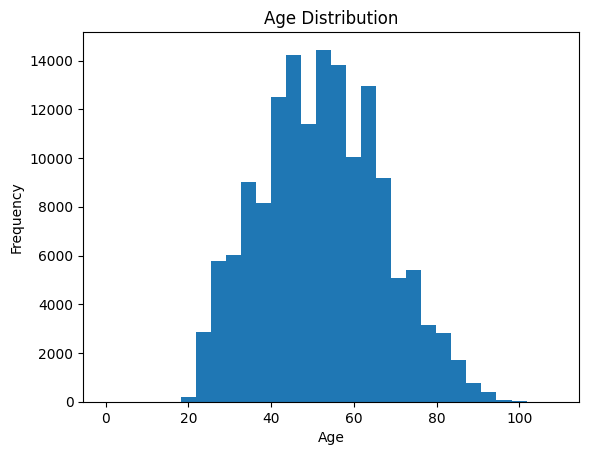

In [11]:
import matplotlib.pyplot as plt

plt.hist(df["age"], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [12]:
df[df["age"] == 0]

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing
65695,65696,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0,0


In [13]:
df = df[df["age"] != 0]

In [14]:
df[df["age"] == 0]

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing


In [15]:
df["age"].min()

np.int64(21)

In [16]:
df["RevolvingUtilizationOfUnsecuredLines"].describe()


count    149999.000000
mean          6.048472
std         249.756203
min           0.000000
25%           0.029867
50%           0.154176
75%           0.559044
max       50708.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

In [17]:
(df["RevolvingUtilizationOfUnsecuredLines"] > 1).sum()


np.int64(3321)

In [18]:
df["RevolvingUtilizationOfUnsecuredLines"] = \
df["RevolvingUtilizationOfUnsecuredLines"].clip(upper=1)

In [19]:
df["RevolvingUtilizationOfUnsecuredLines"].describe()

count    149999.000000
mean          0.319191
std           0.349478
min           0.000000
25%           0.029867
50%           0.154176
75%           0.559044
max           1.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

In [20]:
df["DebtRatio"].describe()

count    149999.000000
mean        353.007426
std        2037.825113
min           0.000000
25%           0.175074
50%           0.366503
75%           0.868257
max      329664.000000
Name: DebtRatio, dtype: float64

In [21]:
df["DebtRatio"].quantile(0.99)

np.float64(4979.079999999958)

In [22]:
cap_value = df["DebtRatio"].quantile(0.99)
df["DebtRatio"] = df["DebtRatio"].clip(upper=cap_value)
df["DebtRatio"].describe()

count    149999.000000
mean        316.551377
std         906.966934
min           0.000000
25%           0.175074
50%           0.366503
75%           0.868257
max        4979.080000
Name: DebtRatio, dtype: float64

In [23]:
df["NumberOfTimes90DaysLate"].describe()

count    149999.000000
mean          0.265975
std           4.169318
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          98.000000
Name: NumberOfTimes90DaysLate, dtype: float64

In [24]:
df["NumberOfTimes90DaysLate"].value_counts()


NumberOfTimes90DaysLate
0     141661
1       5243
2       1555
3        667
4        291
98       264
5        131
6         80
7         38
8         21
9         19
10         8
96         5
11         5
13         4
15         2
14         2
12         2
17         1
Name: count, dtype: int64

In [25]:
df["NumberOfTimes90DaysLate"] = \
df["NumberOfTimes90DaysLate"].clip(upper=10)

In [26]:
df["NumberOfTimes90DaysLate"].value_counts().head(10)

NumberOfTimes90DaysLate
0     141661
1       5243
2       1555
3        667
10       293
4        291
5        131
6         80
7         38
8         21
Name: count, dtype: int64

In [27]:
df.corr()["SeriousDlqin2yrs"].sort_values(ascending=False)

SeriousDlqin2yrs                        1.000000
NumberOfTimes90DaysLate                 0.291353
RevolvingUtilizationOfUnsecuredLines    0.278103
NumberOfTime30-59DaysPastDueNotWorse    0.125587
NumberOfTime60-89DaysPastDueNotWorse    0.102261
NumberOfDependents                      0.046050
Unnamed: 0                              0.002800
NumberRealEstateLoansOrLines           -0.007037
DebtRatio                              -0.017430
MonthlyIncome                          -0.019746
MonthlyIncome_missing                  -0.021309
NumberOfOpenCreditLinesAndLoans        -0.029669
age                                    -0.115397
Name: SeriousDlqin2yrs, dtype: float64

In [28]:
df.drop(columns=["Unnamed: 0"], inplace=True)

In [29]:
df

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
149995,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0,0
149996,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0,0
149997,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0,1
149998,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0,0


In [30]:
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())
df["NumberOfDependents"] = df["NumberOfDependents"].fillna(df["NumberOfDependents"].median())

In [31]:
X = df.drop("SeriousDlqin2yrs", axis=1) #X = özellikler Bağımsız değişkenler
y = df["SeriousDlqin2yrs"] #y = hedef değişken Bağımlı değişken (risk var mı yok mu)

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) #stratify=y ile eğitim ve test setlerinde hedef değişkenin dağılımını koruyoruz. Bu, dengesiz veri setlerinde modelin performansını daha iyi değerlendirmemizi sağlar.

In [33]:
df.isnull().sum()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
MonthlyIncome_missing                   0
dtype: int64

In [34]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter = 1000)


In [35]:

model.fit(X_train, y_train)

c:\Users\gurar\Projects\credit-risk-data\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [36]:
df.isnull().sum()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
MonthlyIncome_missing                   0
dtype: int64

In [37]:
from sklearn.metrics import classification_report 
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.60      0.12      0.20      2005

    accuracy                           0.94     30000
   macro avg       0.77      0.56      0.58     30000
weighted avg       0.92      0.94      0.92     30000



In [38]:
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

c:\Users\gurar\Projects\credit-risk-data\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [39]:
from sklearn.metrics import classification_report
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.98      0.78      0.87     27995
           1       0.20      0.76      0.31      2005

    accuracy                           0.78     30000
   macro avg       0.59      0.77      0.59     30000
weighted avg       0.93      0.78      0.83     30000



In [40]:
y_prob = model.predict_proba(X_test)[:, 1] #pozitif sınıfa ait olasılıkları alır. [:, 1] ifadesi, tüm satırları ve ikinci sütunu (pozitif sınıfın olasılıklarını) seçer.

In [41]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC AUC:", roc_auc)

ROC AUC: 0.8391543110432528


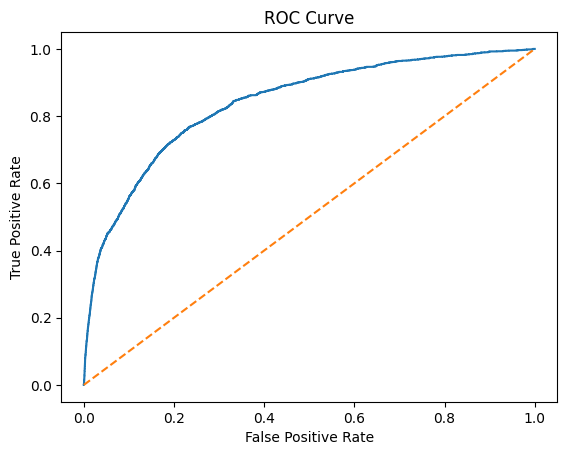

In [42]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1],linestyle='--') # Rastgele sınıflandırıcı için referans çizgisi
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


In [43]:
import numpy as np 
from sklearn.metrics import classification_report

for threshold in [0.5, 0.4, 0.3, 0.2]:
    print(f"\nThreshold: {threshold}")
    y_pred_custom = np.where(y_prob > threshold, 1, 0)  
    print(classification_report(y_test, y_pred_custom))



Threshold: 0.5
              precision    recall  f1-score   support

           0       0.98      0.78      0.87     27995
           1       0.20      0.76      0.31      2005

    accuracy                           0.78     30000
   macro avg       0.59      0.77      0.59     30000
weighted avg       0.93      0.78      0.83     30000


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.98      0.68      0.81     27995
           1       0.16      0.83      0.26      2005

    accuracy                           0.69     30000
   macro avg       0.57      0.75      0.54     30000
weighted avg       0.93      0.69      0.77     30000


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.99      0.54      0.70     27995
           1       0.12      0.89      0.22      2005

    accuracy                           0.57     30000
   macro avg       0.55      0.72      0.46     30000
weighted avg       0.93   

In [44]:
from sklearn.metrics import confusion_matrix

def cost_analysis(threshold, cost_fn =10, cost_fp =1):
    y_pred_custom = (y_prob > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_custom).ravel()

    total_cost = fn * cost_fn + fp * cost_fp
    print("FP:", fp)
    print("FN:", fn)
    print("Total Cost:", total_cost)

for t in [0.5, 0.4, 0.3, 0.2]:
    print(f"\nThreshold: {t}")
    cost_analysis(t)



Threshold: 0.5
FP: 6244
FN: 491
Total Cost: 11154

Threshold: 0.4
FP: 8862
FN: 350
Total Cost: 12362

Threshold: 0.3
FP: 12831
FN: 213
Total Cost: 14961

Threshold: 0.2
FP: 19003
FN: 81
Total Cost: 19813


In [45]:
for t in [0.5, 0.4, 0.3, 0.2]:
    print(f"\nThreshold: {t}")
    cost_analysis(t, cost_fn=20, cost_fp=1)


Threshold: 0.5
FP: 6244
FN: 491
Total Cost: 16064

Threshold: 0.4
FP: 8862
FN: 350
Total Cost: 15862

Threshold: 0.3
FP: 12831
FN: 213
Total Cost: 17091

Threshold: 0.2
FP: 19003
FN: 81
Total Cost: 20623


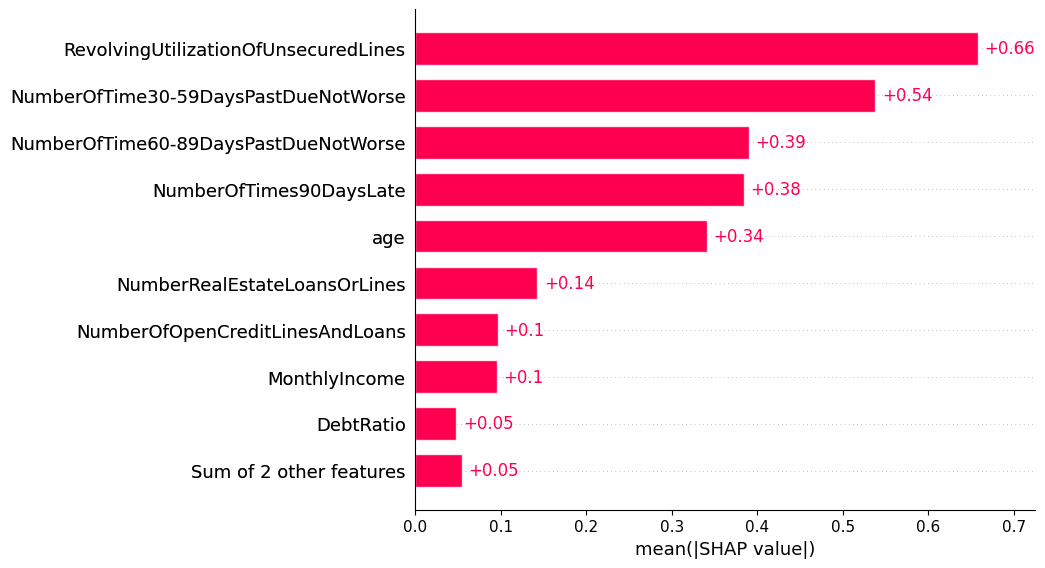

In [46]:
import shap

explainer =shap.Explainer(model, X_train)
shap_values = explainer(X_test) 
shap.plots.bar(shap_values)

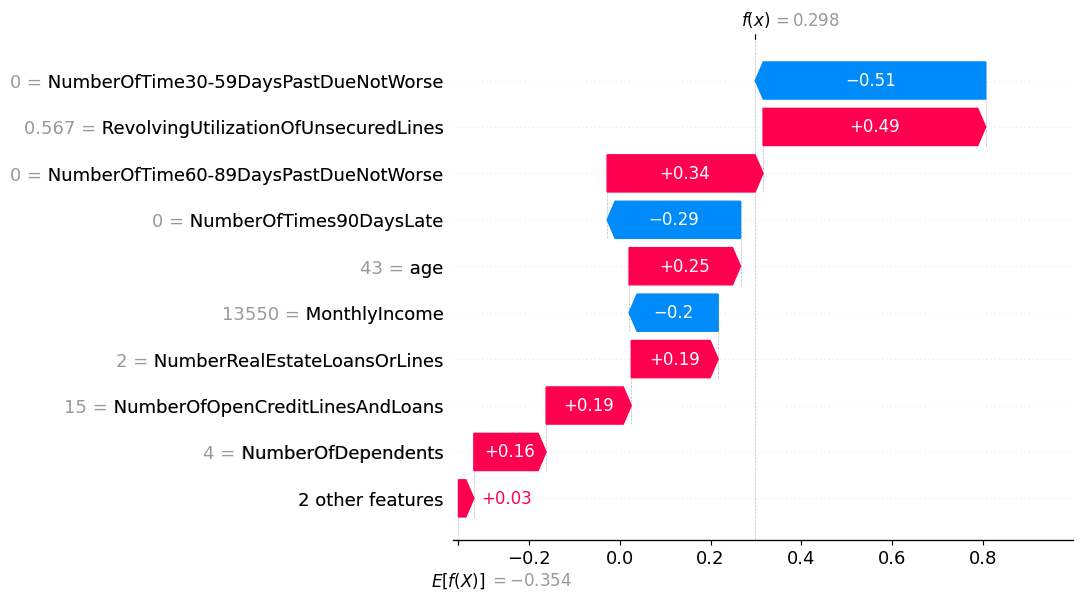

In [47]:
#Test setinden bir müşteri seçelim
index = 5 
shap.plots.waterfall(shap_values[index])

In [48]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report

scale = (y_train == 0).sum() / (y_train == 1).sum()

# XGBoost modeli (başlangıç ayarları)
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale 
)

xgb.fit(X_train, y_train)

# Olasılık ve tahmin
xgb_prob = xgb.predict_proba(X_test)[:, 1]
xgb_pred = (xgb_prob > 0.5).astype(int)

print("XGBoost ROC-AUC:", roc_auc_score(y_test, xgb_prob))
print(classification_report(y_test, xgb_pred))

XGBoost ROC-AUC: 0.8691215789780772
              precision    recall  f1-score   support

           0       0.98      0.81      0.89     27995
           1       0.22      0.78      0.35      2005

    accuracy                           0.80     30000
   macro avg       0.60      0.79      0.62     30000
weighted avg       0.93      0.80      0.85     30000

